# Noise-injection iteration pipeline

Three inputs:
1. Real data -> used only to fit the `slowdown` decay parameter
2. Synthetic data -> used for the noise perturbation sweep
3. Fitted `slowdown` -> passed into every training run

In [2]:
from dlem.api import fetch_band, fit_band_row_profile_sliding
import hictkpy as htk
import os
import re
import pyranges as pr
import numpy as np


def collect_real_band(resolution, region, band_width, dna_ints, output_location,
                      scope="chromosome"):
    """Fetch band(s) from an .mcool for decay fitting.

    Returns a LIST of 2D arrays (one per chromosome), which is what fit_params expects.

    scope="chromosome" -> fetch the full chromosome containing `region` (original behaviour)
    scope="region"     -> fetch only the coordinates given in `region`
    """
    if not htk.is_mcool_file(dna_ints):
        raise ValueError(f"{dna_ints} is not an .mcool file")
    if not resolution:
        raise ValueError("resolution is required when reading an .mcool file")
    if not region:
        raise ValueError("region is required, e.g. 'chr3R:6552201-7088853'")

    cool_filename = f"{dna_ints}::/resolutions/{resolution}"
    with htk.File(dna_ints, resolution) as cool_handle:
        chrom_sizes = cool_handle.chromosomes()
        resolution = cool_handle.resolution()

    # clear any stale prediction file
    os.makedirs(os.path.abspath(output_location), exist_ok=True)
    pred_cool_filename = os.path.join(
        os.path.abspath(output_location),
        os.path.basename(dna_ints).replace(".mcool", "_dlem_pred.cool"),
    )
    if os.path.exists(pred_cool_filename):
        os.remove(pred_cool_filename)

    split_region = re.split(r"[-:]", region)
    chrom = split_region[0]
    if chrom not in chrom_sizes:
        raise ValueError(f"{chrom} not found in file. Available: {list(chrom_sizes)[:10]}")

    if scope == "region":
        regions_gr = pr.PyRanges(
            chromosomes=[chrom],
            starts=[int(split_region[1])],
            ends=[int(split_region[2])],
        )
    else:
        regions_gr = pr.PyRanges(
            chromosomes=[chrom],
            starts=[0],
            ends=[chrom_sizes[chrom]],
        )

    out_data = []
    for cur_chr in regions_gr.chromosomes:
        cur_region = regions_gr[cur_chr].as_df().iloc[0]
        region_name = f"{cur_region.Chromosome}:{cur_region.Start}-{cur_region.End}"
        cur_data = fetch_band(cool_filename,
                              resolution=resolution,
                              cur_region=region_name,
                              width=band_width)
        out_data.append(np.asarray(cur_data))

    return out_data


def _iter_fits(result):
    """Yield every {'params': ...} dict inside a nested fit result."""
    if isinstance(result, dict):
        if "params" in result:
            yield result
        else:
            for value in result.values():
                yield from _iter_fits(value)
    elif isinstance(result, (list, tuple)):
        for value in result:
            yield from _iter_fits(value)


def fit_params(start_diag, decay_extent, window_step, window_size, raw_bands):
    """Fit the row-profile decay and return a single slowdown value."""
    # tolerate a bare 2D array as well as a list of bands
    if isinstance(raw_bands, np.ndarray) and raw_bands.ndim == 2:
        raw_bands = [raw_bands]

    batched_detach_result = []
    for cur_data in raw_bands:
        cur_data = np.asarray(cur_data)
        if cur_data.ndim != 2:
            raise ValueError(f"expected a 2D band, got shape {cur_data.shape}")

        available_rows = cur_data.shape[0] - start_diag
        extent = min(decay_extent, max(available_rows, 1))
        cur_window = min(window_size, cur_data.shape[1])  # local, does not clobber the arg

        batched_detach_result.append(
            fit_band_row_profile_sliding(cur_data,
                                         start_row=start_diag,
                                         extent=extent,
                                         window_size=cur_window,
                                         window_step=window_step,
                                         log_y=True)
        )

    d_values = np.asarray([fit["params"]["d"] for fit in _iter_fits(batched_detach_result)],
                          dtype=float)
    finite = d_values[np.isfinite(d_values)]
    if finite.size == 0:
        raise RuntimeError("Unable to infer slowdown: no valid decay parameters found.")

    return -float(np.median(finite))

In [31]:
def collect_band(filename, resolution, region_name, band_width):
    band = fetch_band(filename,
                      resolution=resolution,
                      cur_region=region_name,
                      width=band_width)
    return np.asarray(band, dtype=float)



def add_noise(band, noise_level, seed=1):
    """Multiplicative uniform noise in [-noise_level, +noise_level], clipped at 0.

    `seed` must differ between repeat iterations or every repeat is identical.
    """
    rng = np.random.default_rng(seed)
    band = np.asarray(band, dtype=float)
    noise = rng.uniform(-1, 1, size=band.shape) * noise_level * band
    return np.clip(band + noise, 0, None)


In [4]:
from dlem.api import train_dlem, generate_dlem_prediction


def train_model(band, train_rows, steps, start_diag, slowdown, lr, iterations):
    return train_dlem(band[0:train_rows, :],
                      steps=steps,
                      start_row=start_diag,
                      slowdown=slowdown,
                      learning_rate=lr,
                      train_steps=iterations)

In [5]:
import jax.numpy as jnp


def normalize_expected_observed(band, log=True, offset=1e-6):
    """Expected/observed normalisation over the upper-triangular part of a band.

    Always returns (normalized, means_expanded) so callers can unpack safely.
    """
    band = jnp.asarray(band, dtype=jnp.float32)
    if band.ndim != 2:
        raise ValueError("normalize_expected_observed expects a 2D array.")

    width, n = band.shape
    if width == 0 or n == 0:
        return jnp.zeros_like(band), jnp.zeros((width, 1), dtype=jnp.float32)

    row_idx = jnp.arange(width, dtype=jnp.int32)[:, None]
    col_idx = jnp.arange(n, dtype=jnp.int32)[None, :]
    mask = col_idx >= row_idx

    masked_band = jnp.where(mask, band, 0.0)
    counts = mask.sum(axis=1).astype(band.dtype)
    sums = masked_band.sum(axis=1)
    means = jnp.where(counts > 0, sums / counts, 0.0)
    means_expanded = means[:, None]

    valid = mask & (means_expanded > 0.0)
    denom = jnp.where(valid, means_expanded, 1.0)
    ratios = jnp.where(valid, (band + offset) / (denom + offset), 1.0)

    if log:
        normalized = jnp.where(valid, jnp.log(ratios), 0.0)
    else:
        normalized = jnp.where(valid, ratios, 0.0)

    return normalized, means_expanded


def reverse_normalize_expected_observed(norm_band, org_means, offset=1e-6, log=True):
    """Invert normalize_expected_observed. `org_means` must come from a band of the
    same number of rows as `norm_band`."""
    norm_band = jnp.asarray(norm_band, dtype=jnp.float32)
    org_means = jnp.asarray(org_means, dtype=jnp.float32)

    if norm_band.ndim != 2:
        raise ValueError("reverse_normalize_expected_observed expects a 2D array.")

    width, n = norm_band.shape
    if width == 0 or n == 0:
        return jnp.zeros_like(norm_band)

    if org_means.ndim == 1:
        org_means = org_means[:, None]
    if org_means.shape[0] != width:
        raise ValueError(
            f"org_means has {org_means.shape[0]} rows but norm_band has {width}. "
            "Compute the means on the same slice you trained on."
        )

    row_idx = jnp.arange(width, dtype=jnp.int32)[:, None]
    col_idx = jnp.arange(n, dtype=jnp.int32)[None, :]
    mask = col_idx >= row_idx

    valid = mask & (org_means > 0.0)
    ratios = jnp.exp(norm_band) if log else norm_band
    recovered = ratios * (org_means + offset) - offset

    return jnp.where(valid, recovered, 0.0)

## Step 1 - fit `slowdown` on the real data

In [6]:
resolution = 1600
region = "chr3R:6552201-7088853"
band_width = 181  # train_rows + steps + 1
dna_ints = '/Users/henrykuerbis/Downloads/dlem/dLEM/tests/GSE263229_GlambdaLmerged_fix.mcool'
output_location = '/Users/henrykuerbis/Downloads/dlem/dLEM/tests/noise_experiment/raw_band'

real_bands = collect_real_band(resolution, region, band_width, dna_ints, output_location,
                               scope="chromosome")
print("bands:", len(real_bands), "shapes:", [b.shape for b in real_bands])

start_diag = 5
decay_extent = 500
window_step = 200
window_size = 3000

slowdown = fit_params(start_diag, decay_extent, window_step, window_size, real_bands)
print("slowdown:", slowdown)

bands: 1 shapes: [(181, 20050)]
slowdown: 0.054713151417550926


/Users/henrykuerbis/Downloads/dlem/dLEM/dlem/api.py:899: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(model, x_fit, y_fit_target, p0=guess, maxfev=10000)


## Step 2 - noise on the synthetic band 

In [26]:
def run_simulation(itr, noise_levels, input_file, resolution, region_name, band_width,
                   train_rows, steps, start_diag, lr, slowdown,
                   iterations=300, base_seed=0, pred_is_normalized=True
                ):
    """Sweep noise levels, repeating `itr` times per level with a different noise draw."""
    results = {}

    # the clean band does not depend on the loop, so fetch it once
    synthetic_band = collect_band(input_file, resolution, region_name, band_width)
    if synthetic_band.shape[0] < train_rows:
        raise ValueError(f"band has {synthetic_band.shape[0]} rows, train_rows={train_rows}")

    run_index = 0
    for noise_level in noise_levels:
        for iteration in range(itr):
            seed = base_seed + run_index
            run_index += 1

            noisy_band = add_noise(synthetic_band, noise_level, seed=seed)
            target = noisy_band[0:train_rows, :]  # what the model actually sees

            model_result = train_model(band=noisy_band,
                                       train_rows=train_rows,
                                       steps=steps,
                                       start_diag=start_diag,
                                       slowdown=slowdown,
                                       lr=lr,
                                       iterations=iterations)

            if run_index == 1:
                print("model_result keys:", list(model_result.keys()))


            pred = np.asarray(model_result["best_normalized_generated"])
            if pred_is_normalized:
                # means must come from the same slice the model trained on
                target = target[(steps-1):, :]
                _, means_expanded = normalize_expected_observed(model_result["best_band"], log=True)

                if pred.ndim == 1:
                    if pred.size != target.size:
                        raise ValueError(
                            f"pred has {pred.size} elements, target slice has {target.size} "
                            f"({target.shape}) — check train_rows/steps"
                        )
                    pred = pred.reshape(target.shape)

                pred = np.asarray(
                    reverse_normalize_expected_observed(pred, means_expanded, 1e-6, log=True)
                )


            if pred.shape != target.shape:
                raise ValueError(f"pred {pred.shape} vs target {target.shape} mismatch")

            mse = float(np.mean((target - pred) ** 2))
            corr = float(np.corrcoef(target.ravel(), pred.ravel())[0, 1])

            record = {
                "left_param": np.asarray(model_result["p_left"]),
                "right_param": np.asarray(model_result["p_right"]),
                "band_mse": mse,
                "band_corr": corr,
                "noise_level": noise_level,
                "iteration": iteration,
                "seed": seed,
                "loss_history": np.asarray(model_result["loss_history"], dtype=np.float32),
                "corr_history": np.asarray(model_result["corr_history"], dtype=np.float32),
                "mse_history": np.asarray(model_result["mse_history"], dtype=np.float32),
                "n_left_saturated": int((np.asarray(model_result["p_left"]) == 1.0).sum()),
                "n_right_saturated": int((np.asarray(model_result["p_right"]) == 1.0).sum()),
            }

            results[(noise_level, iteration)] = record

    results["_clean_band"] = np.asarray(synthetic_band, dtype=np.float32)

    return results

In [32]:
input_file = "/Users/henrykuerbis/Downloads/dlem/dLEM/docs/generated_band_denormalized.mcool"  # <- path to the synthetic .cool / .mcool
noise_levels = [0, .01, .05, .1, .25, .5, .75, 1]
region_name = "chr3R:6552201-7088853"

results = run_simulation(itr=15,
                         noise_levels=noise_levels,
                         input_file=input_file,
                         resolution=1600,
                         region_name=region_name,
                         band_width=181,
                         train_rows=170,
                         steps=10,
                         start_diag=5,
                         lr=0.01,
                         slowdown=slowdown,
                         iterations=300)


runs = {k: v for k, v in results.items() if isinstance(k, tuple)}

for (noise, it), rec in sorted(runs.items()):
    print(f"noise={noise:<6} iter={it}  mse={rec['band_mse']:.6g}  corr={rec['band_corr']:.4f}")


clean_band = results.pop("_clean_band")

import pickle
with open("results_data_logscalenoise.pkl", "wb") as f:
    pickle.dump({"runs": results, "clean_band": clean_band}, f)

/Users/henrykuerbis/Downloads/dlem/dLEM/.pixi/envs/dev/lib/python3.12/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

model_result keys: ['loss_history', 'final_loss', 'p_left', 'p_right', 'corr_history', 'mse_history', 'final_corr', 'final_mse', 'best_corr', 'best_corr_mse', 'best_mse', 'best_corr_params', 'best_mse_params', 'p_left_cor', 'p_right_cor', 'p_left_mse', 'p_right_mse', 'best_corr_band', 'target_band', 'mask', 'noisy_target', 'normalized_target', 'elapsed', 'loss_type', 'weight_power', 'forward_fn_mse_params', 'forward_fn_corr_params', 'final_pred_band', 'final_normalized_generated', 'best_normalized_generated', 'final_centered_gen', 'best_centered_gen', 'final_centered_target', 'best_centered_target', 'best_band', 'best_generated']


noise=0      iter=0  mse=0.0106259  corr=0.9291
noise=0      iter=1  mse=0.0106259  corr=0.9291
noise=0      iter=2  mse=0.0106259  corr=0.9291
noise=0      iter=3  mse=0.0106259  corr=0.9291
noise=0      iter=4  mse=0.0106259  corr=0.9291
noise=0      iter=5  mse=0.0106259  corr=0.9291
noise=0      iter=6  mse=0.0106259  corr=0.9291
noise=0      iter=7  mse=0.0106259  corr=0.9291
noise=0      iter=8  mse=0.0106259  corr=0.9291
noise=0      iter=9  mse=0.0106259  corr=0.9291
noise=0      iter=10  mse=0.0106259  corr=0.9291
noise=0      iter=11  mse=0.0106259  corr=0.9291
noise=0      iter=12  mse=0.0106259  corr=0.9291
noise=0      iter=13  mse=0.0106259  corr=0.9291
noise=0      iter=14  mse=0.0106259  corr=0.9291
noise=0.01   iter=0  mse=0.0106242  corr=0.9291
noise=0.01   iter=1  mse=0.0106274  corr=0.9290
noise=0.01   iter=2  mse=0.0106251  corr=0.9291
noise=0.01   iter=3  mse=0.0106247  corr=0.9291
noise=0.01   iter=4  mse=0.0106242  corr=0.9291
noise=0.01   iter=5  mse=0.01063  c

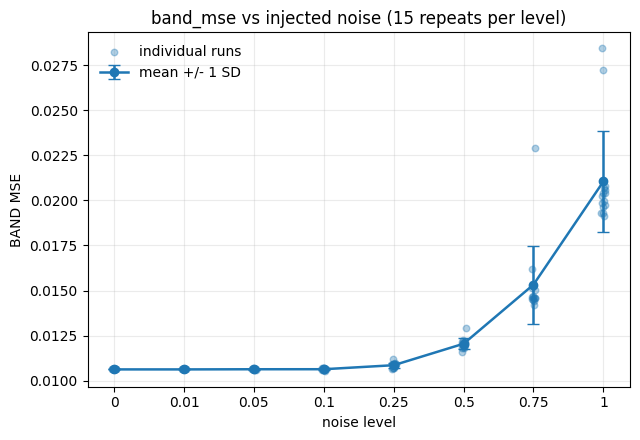

   noise        mean MSE            SD
       0       0.0106259   1.79561e-18
    0.01       0.0106258   2.62986e-06
    0.05       0.0106343   2.10991e-05
     0.1       0.0106356   4.39711e-05
    0.25       0.0108588   0.000135224
     0.5       0.0120489    0.00029749
    0.75        0.015326    0.00215517
       1       0.0210456    0.00281352


In [30]:
import matplotlib.pyplot as plt
from collections import defaultdict


def plot_mse_vs_noise(results, metric="band_mse", log_y=False, categorical_x=True,
                      ax=None, title=None):
    """Plot reconstruction error against injected noise level.

    Each repeat is shown as a light point; the line is the mean per level with
    +/- 1 SD error bars.

    categorical_x=True spaces the levels evenly (readable when the sweep is
    something like [0, 0.01, 0.1]); False plots them on a true linear axis.
    """
    by_noise = defaultdict(list)
    for (noise_level, _iteration), record in results.items():
        by_noise[noise_level].append(record[metric])

    noise_levels = sorted(by_noise)
    if not noise_levels:
        raise ValueError("no results to plot")

    means = np.array([np.mean(by_noise[n]) for n in noise_levels])
    sds = np.array([np.std(by_noise[n], ddof=1) if len(by_noise[n]) > 1 else 0.0
                    for n in noise_levels])

    x = np.arange(len(noise_levels), dtype=float) if categorical_x \
        else np.asarray(noise_levels, dtype=float)

    if ax is None:
        _fig, ax = plt.subplots(figsize=(6.5, 4.5))

    # individual runs, jittered so overlapping repeats stay visible
    span = 0.06 * (1.0 if categorical_x else (max(x) - min(x) + 1e-9))
    for xi, level in zip(x, noise_levels):
        vals = by_noise[level]
        k = len(vals)
        offsets = (np.arange(k) - (k - 1) / 2) * (span / max(k, 1))
        ax.scatter(xi + offsets, vals, s=22, color="tab:blue", alpha=0.35,
                   zorder=2, label="individual runs" if xi == x[0] else None)

    ax.errorbar(x, means, yerr=sds, marker="o", color="tab:blue", capsize=4,
                linewidth=1.8, zorder=3, label="mean +/- 1 SD")

    if categorical_x:
        ax.set_xticks(x)
        ax.set_xticklabels([f"{n:g}" for n in noise_levels])
    if log_y:
        if np.all(means > 0):
            ax.set_yscale("log")
        else:
            print("log_y ignored: a mean is <= 0")

    ax.set_xlabel("noise level")
    ax.set_ylabel(metric.replace("_", " ").upper() if metric == "band_mse" else metric)
    ax.set_title(title or f"{metric} vs injected noise "
                          f"({len(by_noise[noise_levels[0]])} repeats per level)")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()

    summary = {n: (float(m), float(s)) for n, m, s in zip(noise_levels, means, sds)}
    return ax, summary


ax, summary = plot_mse_vs_noise(results, metric="band_mse", log_y=False)
plt.show()

print(f"{'noise':>8}  {'mean MSE':>14}  {'SD':>12}")
for level, (mean, sd) in summary.items():
    print(f"{level:>8g}  {mean:>14.6g}  {sd:>12.6g}")

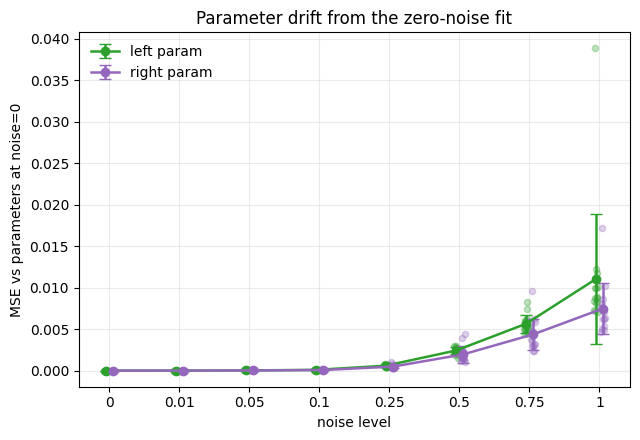


left_param
   noise        mean MSE            SD
       0               0             0
    0.01     9.34458e-07   1.89846e-07
    0.05     2.35289e-05   6.57046e-06
     0.1        8.98e-05    1.5233e-05
    0.25     0.000596736   0.000111656
     0.5      0.00242475   0.000416628
    0.75       0.0056449    0.00107985
       1       0.0110484    0.00784212

right_param
   noise        mean MSE            SD
       0               0             0
    0.01     8.21638e-07   1.71347e-07
    0.05     1.71152e-05   3.64098e-06
     0.1     7.38076e-05   2.40851e-05
    0.25     0.000482511   0.000195597
     0.5      0.00195092   0.000981405
    0.75      0.00436359    0.00189474
       1      0.00749136    0.00309987


In [29]:
def plot_param_mse_vs_noise(results, baseline_noise=0.0,
                            params=("left_param", "right_param"),
                            log_y=False, categorical_x=True, ax=None, title=None):
    """MSE between the parameters recovered at each noise level and those recovered
    at `baseline_noise`.

    The reference is the mean parameter vector across the baseline repeats, so the
    baseline level sits at (near) zero by construction - it is the anchor, not a
    measurement. What matters is how fast l and r pull away from it.
    """
    by_noise = defaultdict(list)
    for (noise_level, _iteration), record in results.items():
        by_noise[noise_level].append(record)

    noise_levels = sorted(by_noise)
    if baseline_noise not in by_noise:
        raise ValueError(f"no runs at noise={baseline_noise}; "
                         f"available levels: {noise_levels}")

    # reference vectors, averaged over the baseline repeats
    reference = {}
    for key in params:
        stacked = np.stack([np.asarray(r[key], dtype=float).ravel()
                            for r in by_noise[baseline_noise]])
        reference[key] = stacked.mean(axis=0)

    per_param = {key: defaultdict(list) for key in params}
    for noise_level in noise_levels:
        for record in by_noise[noise_level]:
            for key in params:
                vec = np.asarray(record[key], dtype=float).ravel()
                if vec.shape != reference[key].shape:
                    raise ValueError(
                        f"{key} at noise={noise_level} has shape {vec.shape}, "
                        f"baseline has {reference[key].shape}"
                    )
                per_param[key][noise_level].append(float(np.mean((vec - reference[key]) ** 2)))

    x = np.arange(len(noise_levels), dtype=float) if categorical_x \
        else np.asarray(noise_levels, dtype=float)

    if ax is None:
        _fig, ax = plt.subplots(figsize=(6.5, 4.5))

    colors = ["tab:green", "tab:purple", "tab:red", "tab:brown"]
    span = 0.10 * (1.0 if categorical_x else (max(x) - min(x) + 1e-9))
    summary = {}

    for p_i, key in enumerate(params):
        color = colors[p_i % len(colors)]
        # nudge each parameter series sideways so the error bars don't collide
        shift = (p_i - (len(params) - 1) / 2) * span
        means = np.array([np.mean(per_param[key][n]) for n in noise_levels])
        sds = np.array([np.std(per_param[key][n], ddof=1) if len(per_param[key][n]) > 1 else 0.0
                        for n in noise_levels])

        for xi, level in zip(x, noise_levels):
            vals = per_param[key][level]
            k = len(vals)
            offsets = (np.arange(k) - (k - 1) / 2) * (span / max(k, 1) * 0.6)
            ax.scatter(xi + shift + offsets, vals, s=20, color=color, alpha=0.30, zorder=2)

        ax.errorbar(x + shift, means, yerr=sds, marker="o", color=color, capsize=4,
                    linewidth=1.8, zorder=3, label=key.replace("_", " "))
        summary[key] = {n: (float(m), float(s)) for n, m, s in zip(noise_levels, means, sds)}

    if categorical_x:
        ax.set_xticks(x)
        ax.set_xticklabels([f"{n:g}" for n in noise_levels])
    if log_y:
        if all(np.mean(per_param[k][n]) > 0
               for k in params for n in noise_levels if n != baseline_noise):
            ax.set_yscale("symlog", linthresh=1e-12)
        else:
            print("log_y ignored: a non-baseline mean is <= 0")

    ax.set_xlabel("noise level")
    ax.set_ylabel(f"MSE vs parameters at noise={baseline_noise:g}")
    ax.set_title(title or "Parameter drift from the zero-noise fit")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()

    return ax, summary


ax, param_summary = plot_param_mse_vs_noise(results, baseline_noise=0.0, log_y=False)
plt.show()

for key, per_level in param_summary.items():
    print(f"\n{key}")
    print(f"{'noise':>8}  {'mean MSE':>14}  {'SD':>12}")
    for level, (mean, sd) in per_level.items():
        print(f"{level:>8g}  {mean:>14.6g}  {sd:>12.6g}")

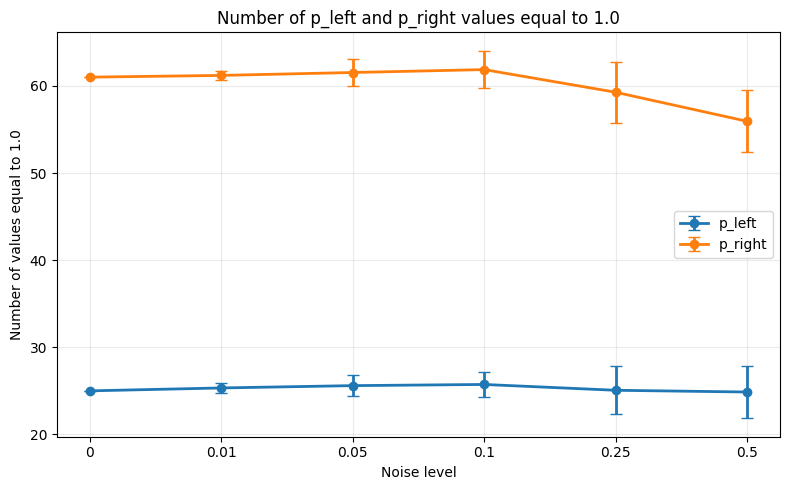

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Store number of 1.0 values by noise level
by_noise = defaultdict(lambda: {"left": [], "right": []})

for (noise_level, iteration), record in results.items():
    p_left = np.asarray(record["left_param"])
    p_right = np.asarray(record["right_param"])

    # Count how many values are exactly 1.0
    n_left_ones = np.sum(p_left == 1.0)
    n_right_ones = np.sum(p_right == 1.0)

    by_noise[noise_level]["left"].append(n_left_ones)
    by_noise[noise_level]["right"].append(n_right_ones)

# Sort noise levels
noise_levels = sorted(by_noise)

# Calculate mean and SD across runs
left_means = [np.mean(by_noise[n]["left"]) for n in noise_levels]
left_sds = [np.std(by_noise[n]["left"], ddof=1) for n in noise_levels]

right_means = [np.mean(by_noise[n]["right"]) for n in noise_levels]
right_sds = [np.std(by_noise[n]["right"], ddof=1) for n in noise_levels]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(noise_levels))

ax.errorbar(
    x,
    left_means,
    yerr=left_sds,
    marker="o",
    capsize=4,
    linewidth=2,
    label="p_left"
)

ax.errorbar(
    x,
    right_means,
    yerr=right_sds,
    marker="o",
    capsize=4,
    linewidth=2,
    label="p_right"
)

ax.set_xticks(x)
ax.set_xticklabels([f"{n:g}" for n in noise_levels])
ax.set_xlabel("Noise level")
ax.set_ylabel("Number of values equal to 1.0")
ax.set_title("Number of p_left and p_right values equal to 1.0")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

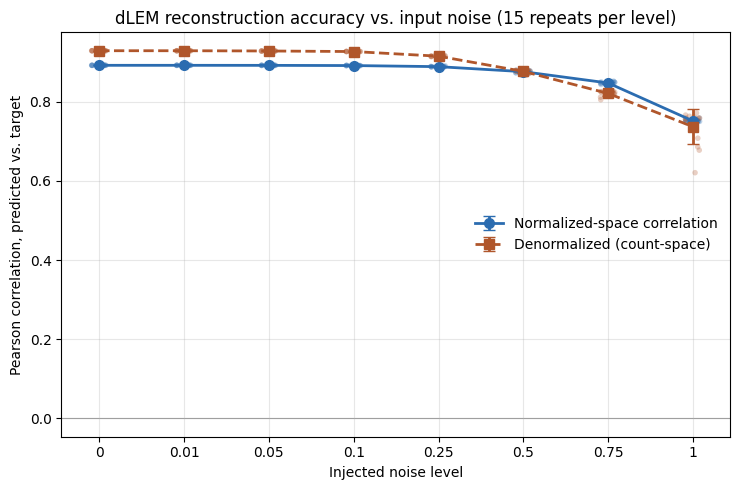

  noise   Normalized-space corre   Denormalized (count-sp
      0        0.89226 ±0.0000        0.92913 ±0.0000
   0.01        0.89226 ±0.0000        0.92910 ±0.0000
   0.05        0.89215 ±0.0001        0.92847 ±0.0001
    0.1        0.89163 ±0.0003        0.92705 ±0.0003
   0.25        0.88887 ±0.0008        0.91532 ±0.0011
    0.5        0.87618 ±0.0021        0.87686 ±0.0033
   0.75        0.84756 ±0.0025        0.82118 ±0.0059
      1        0.75160 ±0.0032        0.73709 ±0.0436


In [33]:
import numpy as np
import matplotlib.pyplot as plt


def corr_at_best_mse(rec):
    """Correlation at the checkpoint where MSE was lowest (same step best_band is saved)."""
    mse_h = np.asarray(rec["mse_history"])
    corr_h = np.asarray(rec["corr_history"])
    return float(corr_h[int(np.argmin(mse_h[:, 1])), 1])


def plot_corr_vs_noise(results, also_plot_band_corr=True, savepath=None):
    runs = {k: v for k, v in results.items() if isinstance(k, tuple)}
    levels = sorted({k[0] for k in runs})
    x = np.arange(len(levels))                      # categorical spacing

    series = [("Normalized-space correlation", corr_at_best_mse, "#2b6cb0", "o", "-")]
    if also_plot_band_corr and "band_corr" in next(iter(runs.values())):
        series.append(("Denormalized (count-space)",
                       lambda r: float(r["band_corr"]), "#b0562b", "s", "--"))

    fig, ax = plt.subplots(figsize=(7.5, 5))
    summary = {}

    for label, getter, color, marker, ls in series:
        vals = [np.array([getter(runs[k]) for k in runs if k[0] == L]) for L in levels]
        means = np.array([v.mean() for v in vals])
        sds = np.array([v.std(ddof=1) if v.size > 1 else 0.0 for v in vals])

        for xi, v in zip(x, vals):                  # individual runs, jittered
            jit = (np.random.default_rng(0).random(v.size) - 0.5) * 0.18
            ax.scatter(xi + jit, v, s=16, color=color, alpha=0.28,
                       edgecolors="none", zorder=2)

        ax.errorbar(x, means, yerr=sds, color=color, marker=marker, linestyle=ls,
                    capsize=4, linewidth=2, markersize=7, zorder=3, label=label)
        summary[label] = (means, sds)

    ax.set_xticks(x)
    ax.set_xticklabels([str(L) for L in levels])
    ax.set_xlabel("Injected noise level")
    ax.set_ylabel("Pearson correlation, predicted vs. target")
    ax.set_title(f"dLEM reconstruction accuracy vs. input noise "
                 f"({len(runs)//len(levels)} repeats per level)")
    ax.axhline(0, color="0.6", linewidth=0.8, zorder=1)
    ax.grid(alpha=0.3, zorder=0)
    ax.legend(frameon=False)
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")   # use .svg for the poster
    plt.show()

    print(f"{'noise':>7}", *[f"{lbl[:22]:>24}" for lbl in summary])
    for i, L in enumerate(levels):
        row = "".join(f"{summary[lbl][0][i]:>15.5f} ±{summary[lbl][1][i]:.4f}"
                      for lbl in summary)
        print(f"{L:>7}{row}")

    return summary


summary = plot_corr_vs_noise(results, savepath="corr_vs_noise.svg")

In [12]:
result = results[(0, 0)]

p_left = result["left_param"]
p_right = result["right_param"]

print("p_left:", len(p_left))
print("p_right:", len(p_right))

p_left: 336
p_right: 336


#todo
add noise to L and R
call forward generate
measure mse of new pred_band

considerations
- mse betwen band generated from noisy params and band from non-noisy params or band params where found from?
- test generated_dlem_pred on L and R see if it makes a similar band to pred_band as check if the mse with the input_band is the same